In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('../data/cleaned_ecommerce.csv')

In [3]:
df.head()

,age,gender,country,city,membership_years,login_frequency,session_duration_avg,pages_per_session,cart_abandonment_rate,wishlist_items,...,customer_service_calls,product_reviews_written,social_media_engagement_score,mobile_app_usage,payment_method_diversity,lifetime_value,credit_balance,churned,signup_quarter,membership_years_round
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,5.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1,3.0
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,5.0,3.0,34.3,23.3,3.0,1067.47,3028.0,0,Q4,2.0
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,5.0,1.0,24.3,8.8,2.0,1289.75,2317.0,0,Q4,3.0
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,5.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1,3.0
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.3,19.1,9.0,...,5.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4,3.0


In [4]:
df.isnull().sum().mean()*100

np.float64(0.0)

In [5]:
df.columns

Index(['age', 'gender', 'country', 'city', 'membership_years',
       'login_frequency', 'session_duration_avg', 'pages_per_session',
       'cart_abandonment_rate', 'wishlist_items', 'total_purchases',
       'average_order_value', 'days_since_last_purchase',
       'discount_usage_rate', 'returns_rate', 'email_open_rate',
       'customer_service_calls', 'product_reviews_written',
       'social_media_engagement_score', 'mobile_app_usage',
       'payment_method_diversity', 'lifetime_value', 'credit_balance',
       'churned', 'signup_quarter', 'membership_years_round'],
      dtype='str')

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  float64
 1   gender                         50000 non-null  str    
 2   country                        50000 non-null  str    
 3   city                           50000 non-null  str    
 4   membership_years               50000 non-null  float64
 5   login_frequency                50000 non-null  float64
 6   session_duration_avg           50000 non-null  float64
 7   pages_per_session              50000 non-null  float64
 8   cart_abandonment_rate          50000 non-null  float64
 9   wishlist_items                 50000 non-null  float64
 10  total_purchases                50000 non-null  float64
 11  average_order_value            50000 non-null  float64
 12  days_since_last_purchase       50000 non-null  float64
 1

# 1. Univariate Analysis

(a) Lifetime Value → Histogram + KDE

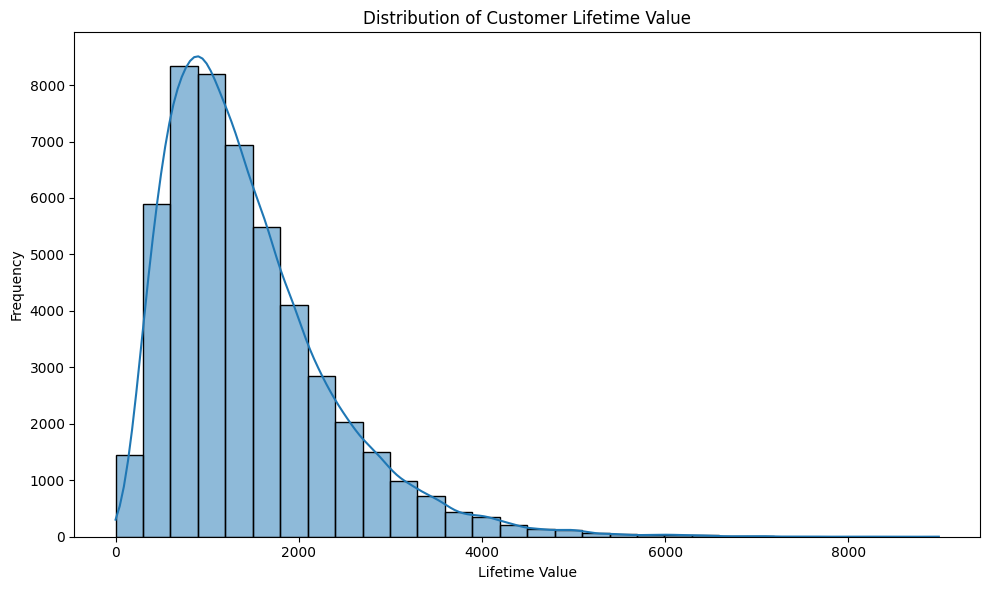

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['lifetime_value'],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("Lifetime Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

(b) Churned → Countplot

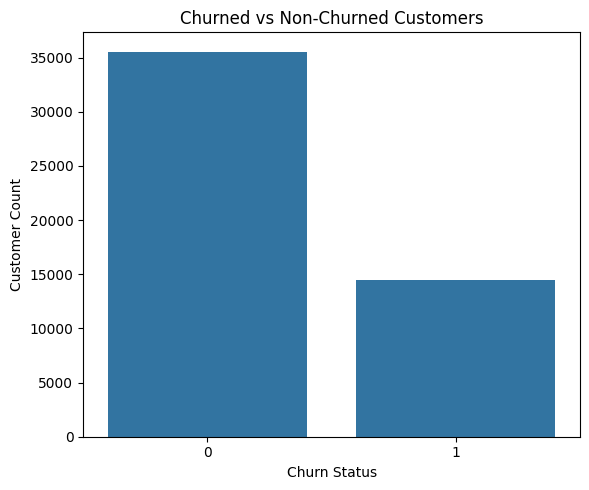

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='churned',
    data=df
)

plt.title("Churned vs Non-Churned Customers")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.show()

(c) Average Order Value → Histogram

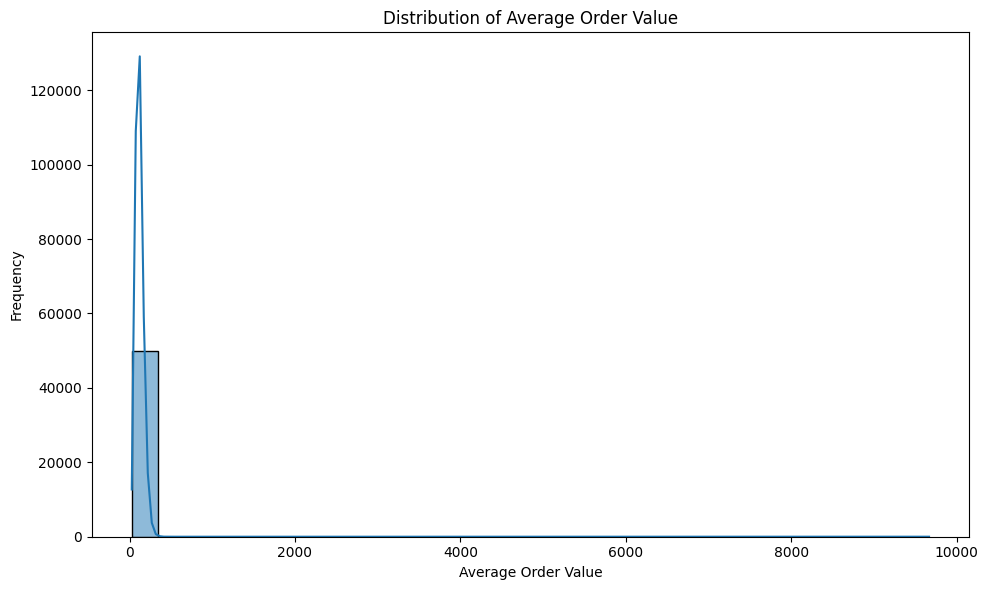

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['average_order_value'],
    bins=30,
    kde=True
)

plt.title("Distribution of Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

(d) Cart Abandonment Rate → Density Plot

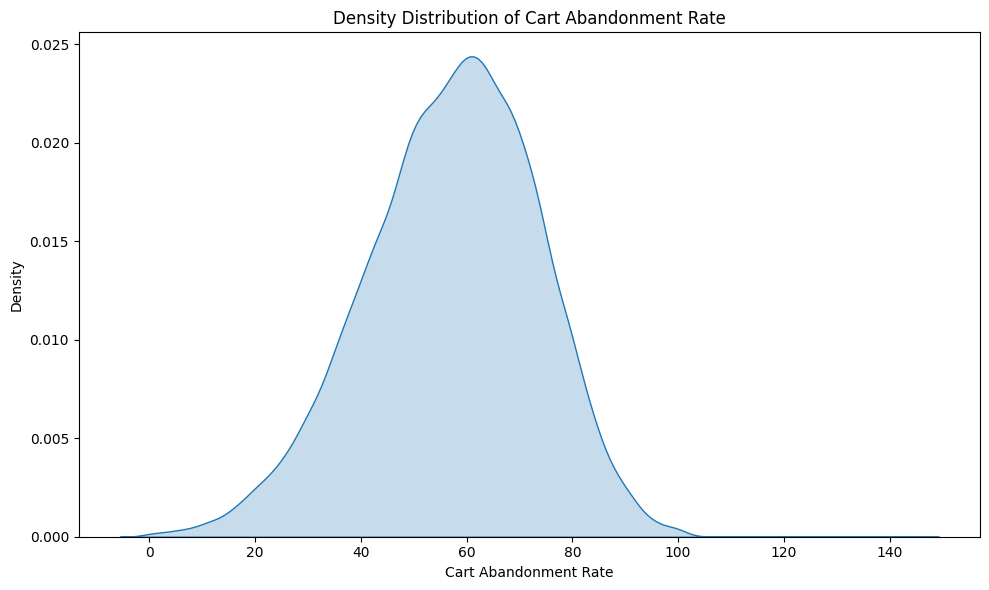

In [11]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    df['cart_abandonment_rate'],
    fill=True
)

plt.title("Density Distribution of Cart Abandonment Rate")
plt.xlabel("Cart Abandonment Rate")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

(e) Age → Boxplot

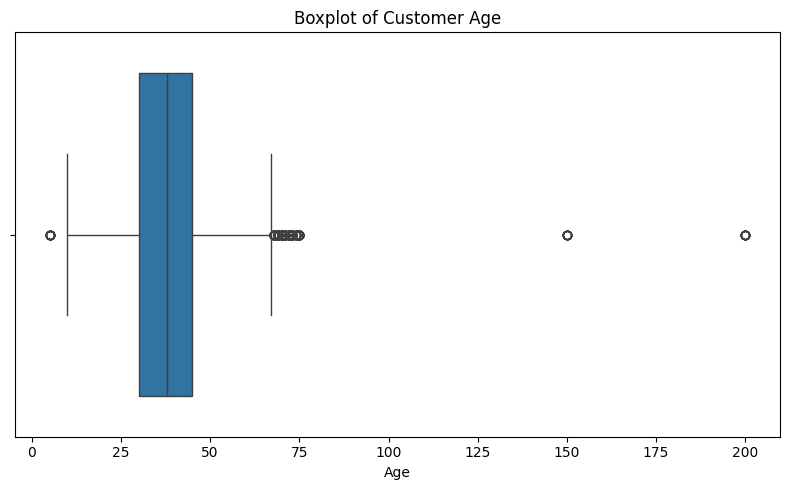

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['age']
)

plt.title("Boxplot of Customer Age")
plt.xlabel("Age")

plt.tight_layout()
plt.show()

# 2. Bivariate Analysis 

(a). Scatter Plot --> session_duration_avg vs pages_per_session [Numeric vs Numeric]

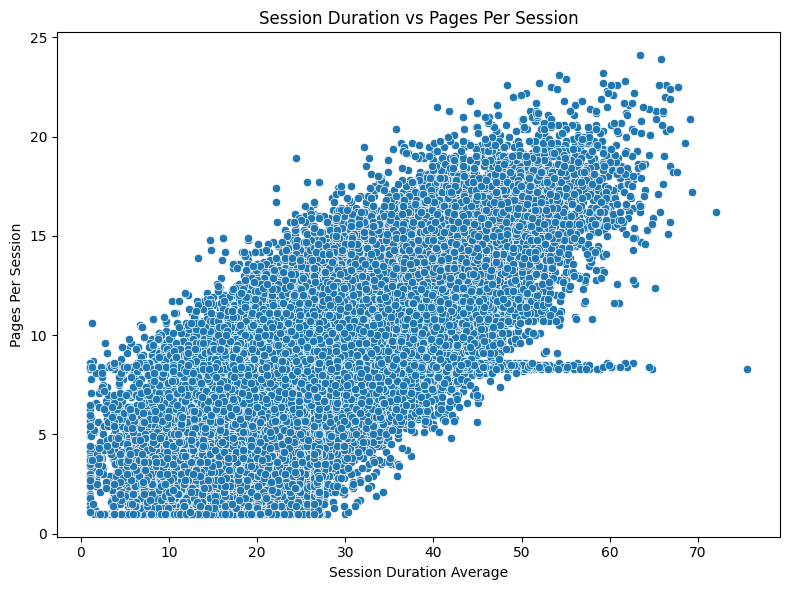

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='session_duration_avg',
    y='pages_per_session',
    data=df
)

plt.title("Session Duration vs Pages Per Session")
plt.xlabel("Session Duration Average")
plt.ylabel("Pages Per Session")

plt.tight_layout()
plt.show()

(b). Line Chart --> total_purchases vs average_order_value [Numeric vs Numeric]

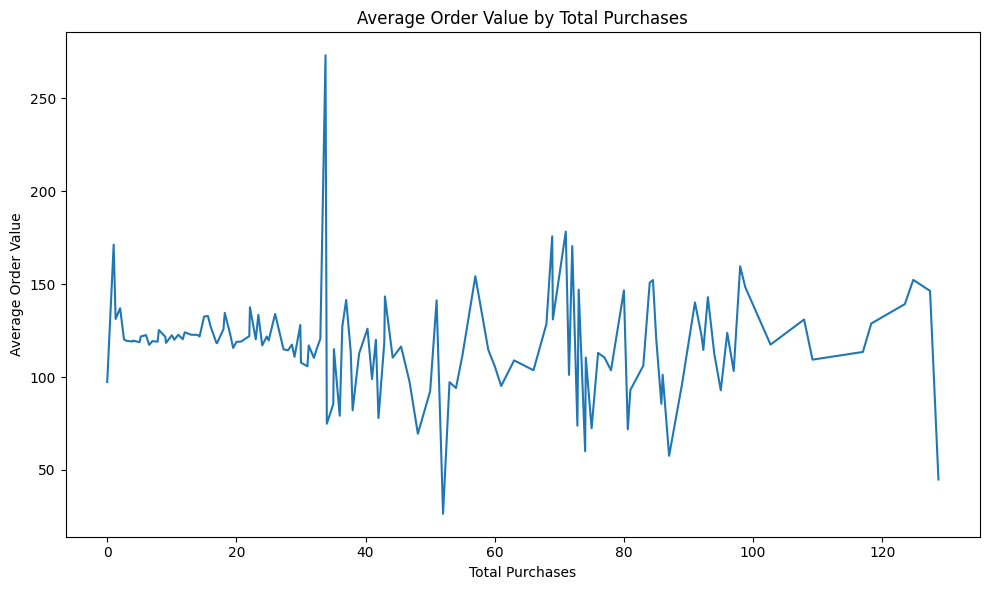

In [21]:
purchase_avg = (
    df.groupby('total_purchases')['average_order_value']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    x='total_purchases',
    y='average_order_value',
    data=purchase_avg
)

plt.title("Average Order Value by Total Purchases")
plt.xlabel("Total Purchases")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

(C). Correlation Heatmap --> cart_abandonment_rate vs lifetime_value [Numeric vs Numeric]

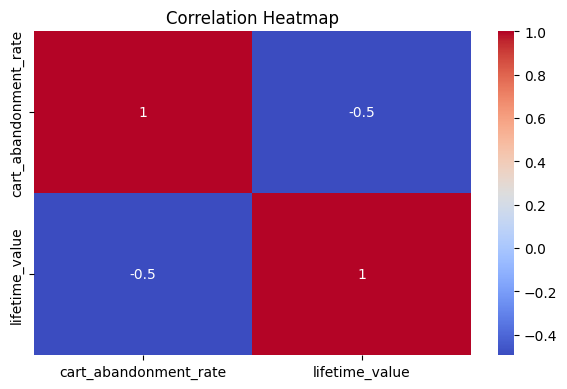

In [22]:
plt.figure(figsize=(6,4))

corr = df[['cart_abandonment_rate', 'lifetime_value']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

(D). Box Plot --> age vs gender  [Numeric vs Categorical]

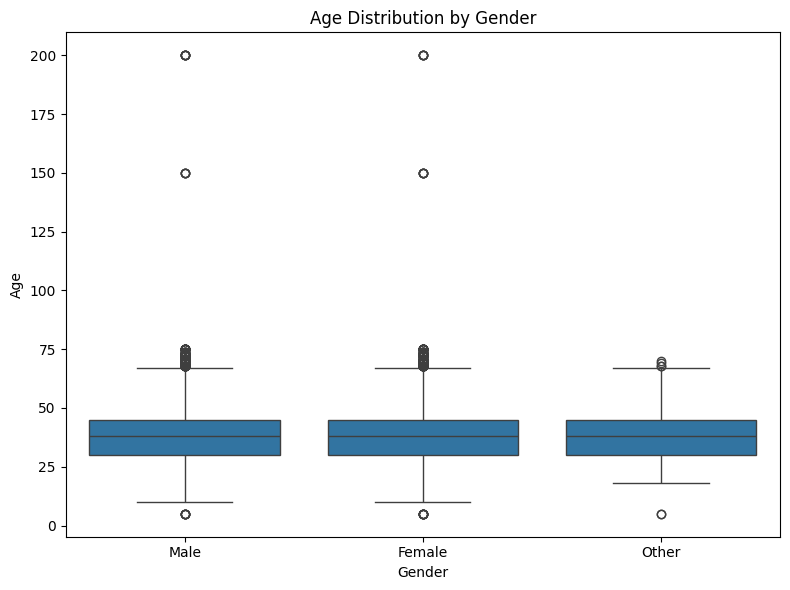

In [23]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='gender',
    y='age',
    data=df
)

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

(E). Bar Chart --> average_order_value vs country [Numeric vs Categorical]

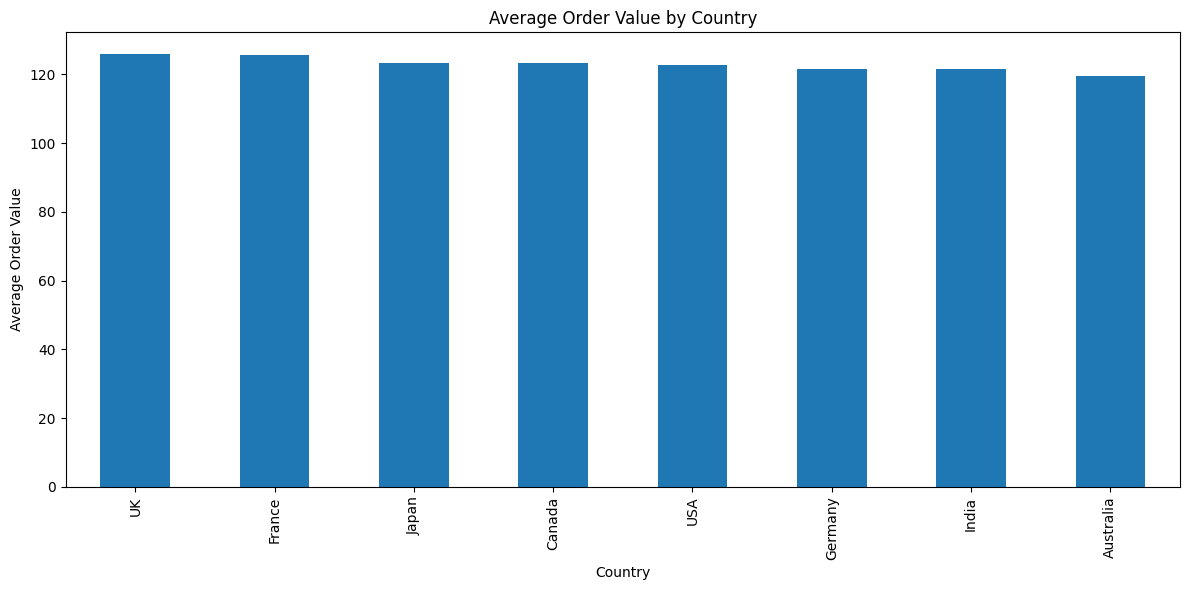

In [24]:
top_country = (
    df.groupby('country')['average_order_value']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_country.plot(kind='bar')

plt.title("Average Order Value by Country")
plt.xlabel("Country")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

(F). Grouped Bar Chart --> gender vs churned  [Categorical vs Categorical]

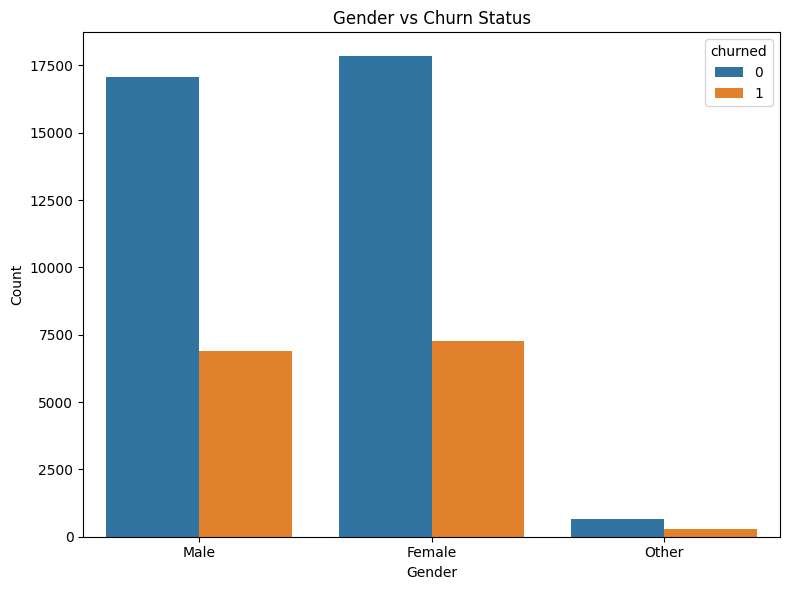

In [25]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='gender',
    hue='churned',
    data=df
)

plt.title("Gender vs Churn Status")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# 3. Multivariate Analysis 

1. CORRELATION HEATMAP (email_open_rate, social_media_engagement_score, mobile_app_usage)

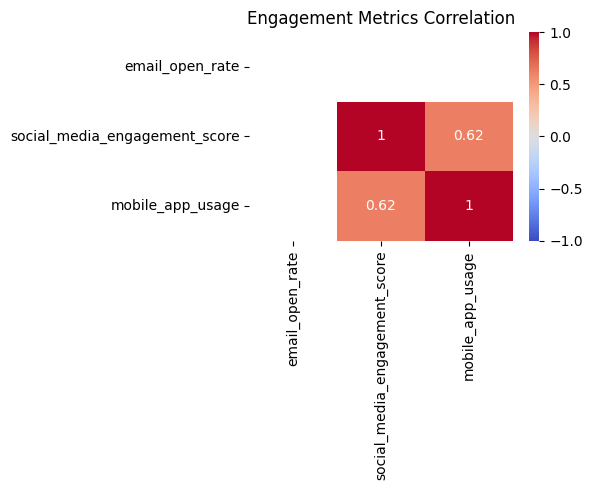

In [26]:
plt.figure(figsize=(6,5))

engagement_corr = df[
    ['email_open_rate', 'social_media_engagement_score', 'mobile_app_usage']
].corr()

sns.heatmap(
    engagement_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1
)

plt.title("Engagement Metrics Correlation")

plt.tight_layout()
plt.show()

2. PAIRPLOT (age, login_frequency, mobile_app_usage, lifetime_value)

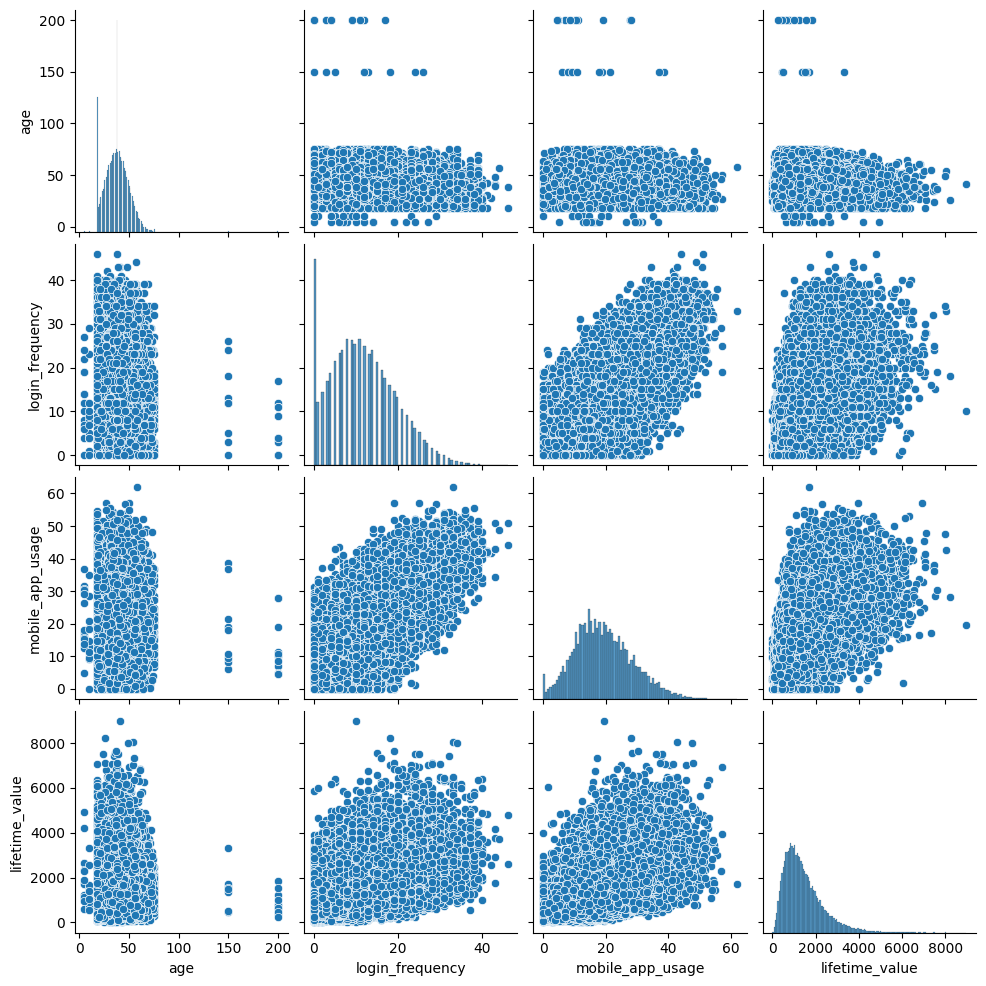

In [27]:
sns.pairplot(
    df[['age', 'login_frequency', 'mobile_app_usage', 'lifetime_value']]
)

plt.show()

3. BUBBLE CHART (total_purchases, wishlist_items, credit_balance (bubble size))

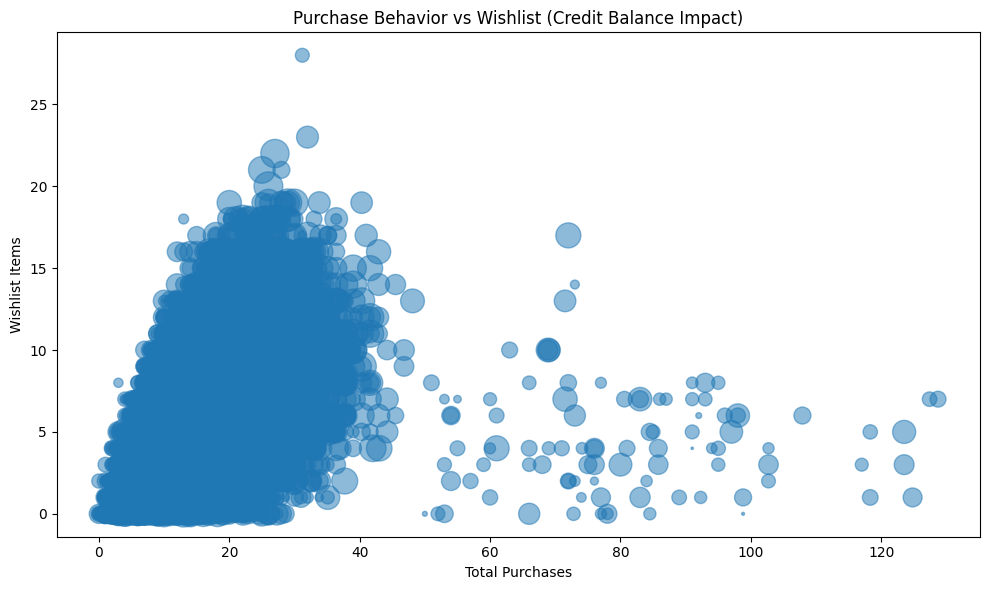

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

bubble_size = scaler.fit_transform(df[['credit_balance']])

plt.figure(figsize=(10,6))

plt.scatter(
    df['total_purchases'],
    df['wishlist_items'],
    s=bubble_size.flatten() * 500,
    alpha=0.5
)

plt.title("Purchase Behavior vs Wishlist (Credit Balance Impact)")
plt.xlabel("Total Purchases")
plt.ylabel("Wishlist Items")

plt.tight_layout()
plt.show()

4. CORRELATION MATRIX (Relationship: Overall Feature Relationships)

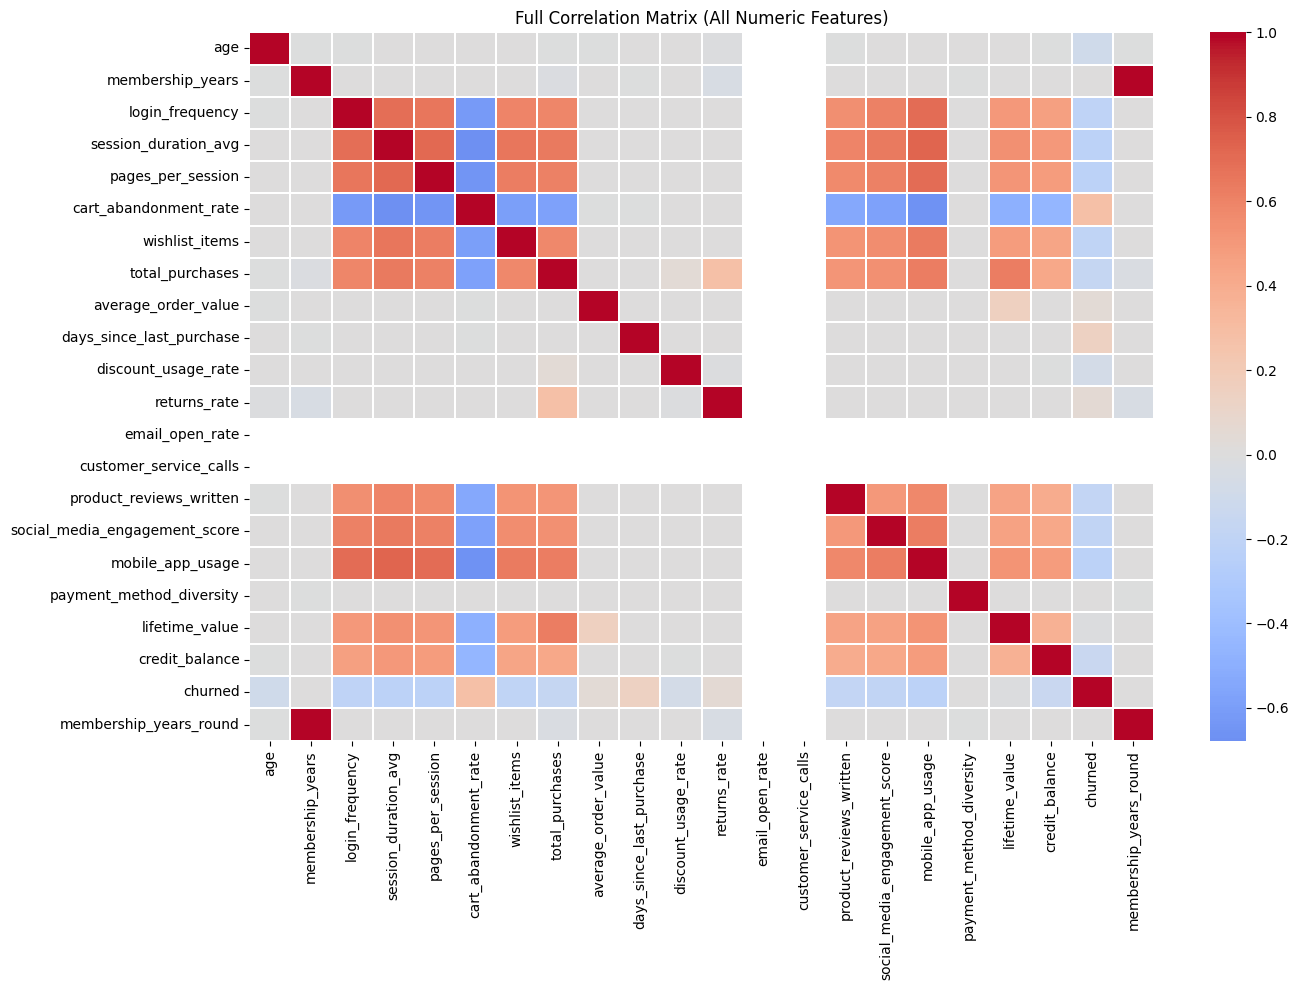

In [29]:
plt.figure(figsize=(14,10))

corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)

plt.title("Full Correlation Matrix (All Numeric Features)")

plt.tight_layout()
plt.show()